In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

%matplotlib inline

In [2]:
df_index = pd.read_csv(r"../datasets/economic_index.csv")
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [3]:
# Dropping un-necessary features
df_index.drop(['Unnamed: 0','year','month'],axis=1,inplace=True)

In [4]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [5]:
#Checking the null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

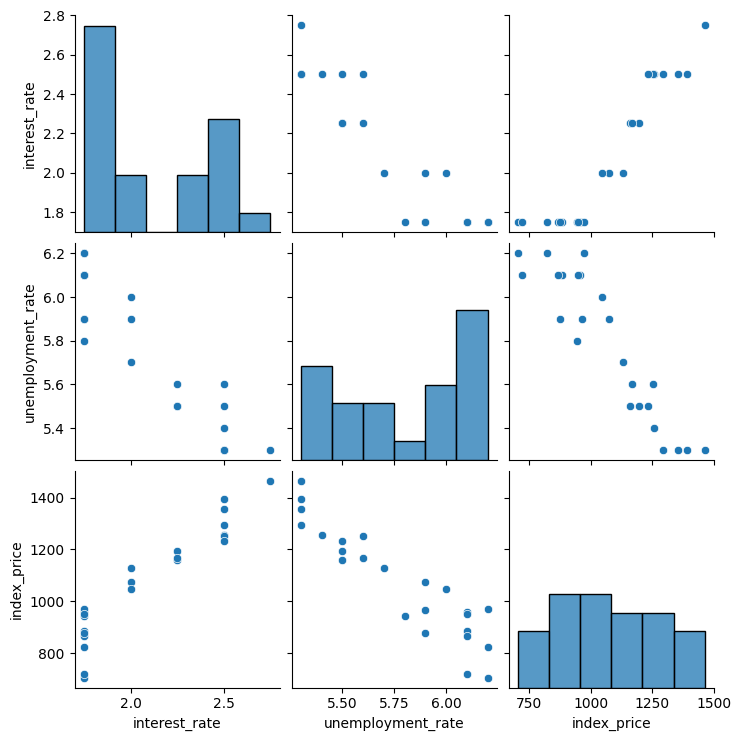

In [6]:
# Visualization
import seaborn as sns

sns.pairplot(df_index)

In [7]:
# Checking correlation
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment rate')

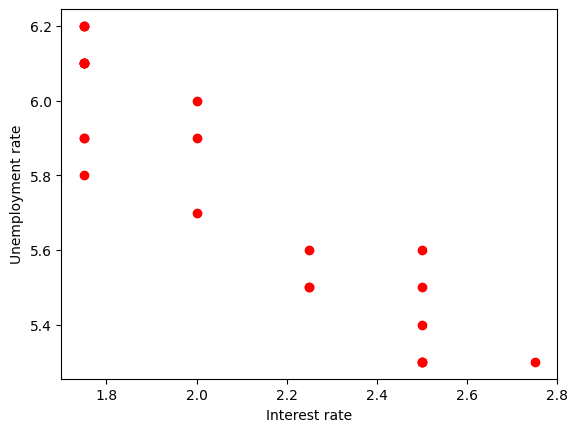

In [10]:
# Visualize the datapoints more clearly
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("Interest rate")
plt.ylabel("Unemployment rate")

### Using regression plots to see best fit line between the two features (Helpful for understanding correlation)

<Axes: xlabel='interest_rate', ylabel='index_price'>

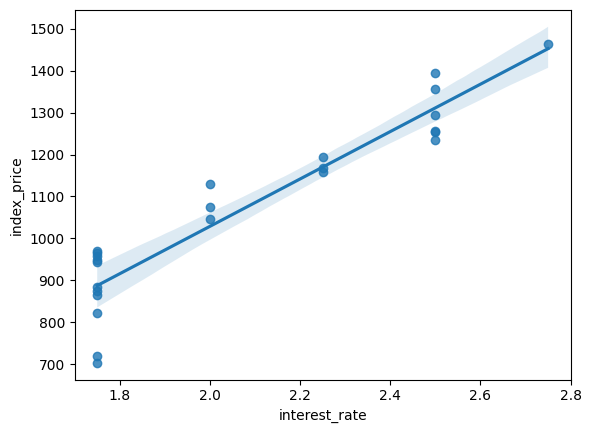

In [18]:
# Finding correlation between index_price and interest rate
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

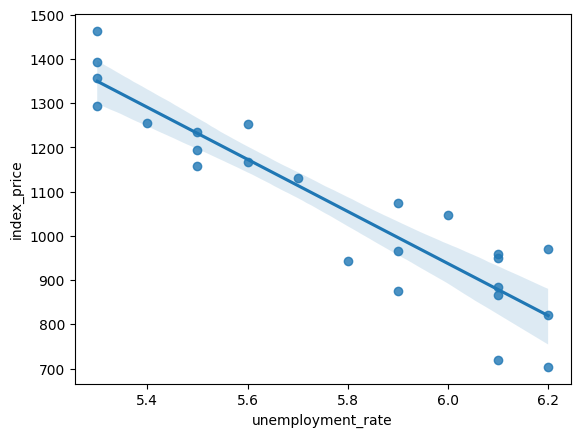

In [20]:
# Finding correlation between unemployment rate and interest rate
sns.regplot(x=df_index['unemployment_rate'],y=df_index['index_price'])

### Splitting the dataset and preparing for model training

In [11]:
# Independent and dependent features
X = df_index[['interest_rate','unemployment_rate']]
Y = df_index[['index_price']]

In [12]:
# Independent feature
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [13]:
# Dependent feature
Y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [15]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [22]:
X_train = scalar.fit_transform(X_train)
X_test = scalar.fit_transform(X_test)

In [23]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [24]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [25]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Cross validation

In [26]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,Y_train,scoring='neg_mean_squared_error',cv=3)

In [27]:
np.mean(validation_score)

np.float64(-5914.828180162386)

### Prediction

In [28]:
Y_pred = regression.predict(X_test)
Y_pred

array([[1180.7466813 ],
       [ 802.74279699],
       [1379.83457045],
       [ 838.52599602],
       [ 973.85313963],
       [1144.96348227]])

In [29]:
# Performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error, root_mean_squared_error

mse = mean_squared_error(Y_test,Y_pred)
mae = mean_absolute_error(Y_test,Y_pred)
rmse = root_mean_squared_error(Y_test,Y_pred)

print(f"Root mean squared error is : {rmse}")
print(f"Mean absolute error is : {mae}")
print(f"Mean squared errors is : {mse}")

Root mean squared error is : 90.04758423359621
Mean absolute error is : 73.80444932337097
Mean squared errors is : 8108.567426306604


In [30]:
from sklearn.metrics import r2_score

score = r2_score(Y_test,Y_pred)
adjusted_score = 1 - (1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

print(f"R-square score is : {score}")
print(f"Adjusted R-square score is : {adjusted_score}")

R-square score is : 0.7591371539010257
Adjusted R-square score is : 0.5985619231683761


### Assumptions

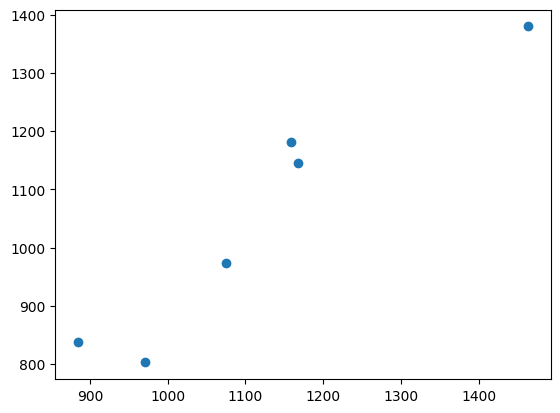

In [31]:
plt.scatter(Y_test,Y_pred)

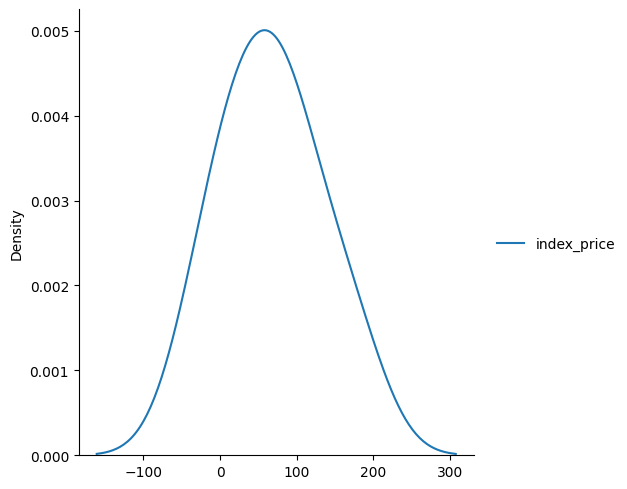

In [32]:
residuals = Y_test - Y_pred
sns.displot(residuals,kind='kde')

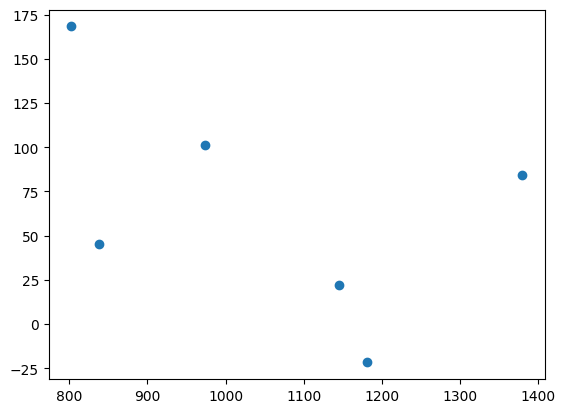

In [33]:
# Scatter plot with respect to prediction and residuals
plt.scatter(Y_pred,residuals)

### Checking with OLS

In [34]:
import statsmodels.api as sm
model = sm.OLS(Y_train,X_train).fit()

In [35]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sat, 23 May 2026   Prob (F-statistic):                       0.754
Time:                        06:36:33   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
## Coefficients obtained by traditional method
regression.coef_

array([[  88.27275507, -116.25716066]])